## Part 1: Helping functions and data loading

In [1]:
# Do not modify this cell, this is only for ploting the clusters
import matplotlib.pyplot as plt

def plot_clustering_result(X, labels, EPS, MIN_POINTS, title=None):
    title = title or "clustering result"
    fig, ax = plt.subplots(figsize=(6, 5))
    noise = labels == -1
    if noise.any():
        ax.scatter(X[noise, 0], X[noise, 1], s=18, marker="x", c="k", alpha=0.9, label="noise (-1)")
    for k in sorted(set(labels) - {-1}):
        ax.scatter(X[labels == k, 0], X[labels == k, 1], s=18, alpha=0.9, label=f"cluster {k}")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_title(title)
    ax.legend(loc="best", frameon=True)
    ax.grid(True)
    plt.savefig("DBScan("+str(EPS)+","+str(MIN_POINTS)+")Clustering.png")
    plt.show()

def plot_clustering_centroid_result(X, labels, centroids, title=None):
    title = title or "clustering result"
    fig, ax = plt.subplots(figsize=(6, 5))
    noise = labels == -1
    if noise.any():
        ax.scatter(X[noise, 0], X[noise, 1], s=18, marker="x", c="k", alpha=0.9, label="noise (-1)")
    for k in sorted(set(labels) - {-1}):
        ax.scatter(X[labels == k, 0], X[labels == k, 1], s=18, alpha=0.9, label=f"cluster {k}")
    ax.scatter(centroids[:, 0],centroids[:, 1],s=100,marker="*",c="red",edgecolors="black",linewidths=1,label="centroid")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_title(title)
    ax.legend(loc="best", frameon=True)
    ax.grid(True)
    plt.savefig("Kmeans" + str(centroids.shape[0]) + "Clustering.png")
    plt.show()

In [2]:
# loading data
import numpy as np
X = np.load("part1_data.npz")["X"]
print(X.shape)
print(X[:5])

(1400, 2)
[[-8.48190163 -4.36549386]
 [-8.21067118 -4.44820716]
 [ 4.84501768 -0.06097765]
 [ 5.07049438  0.1960901 ]
 [-8.18911984 -3.5381329 ]]


## K-means experiments

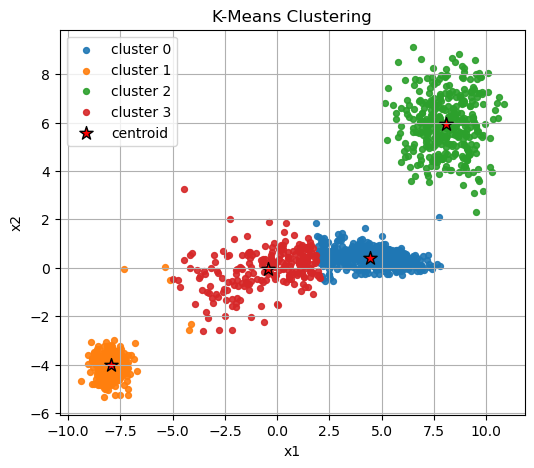

In [3]:
from sklearn.cluster import KMeans

# Number of clusters
K = 4

# Fit K-means and get labels
km = KMeans(n_clusters=K, random_state=2, n_init="auto").fit(X)
labels = km.labels_

# ploting data
plot_clustering_centroid_result(X, labels, km.cluster_centers_, title="K-Means Clustering")

## DBSCAN experiments

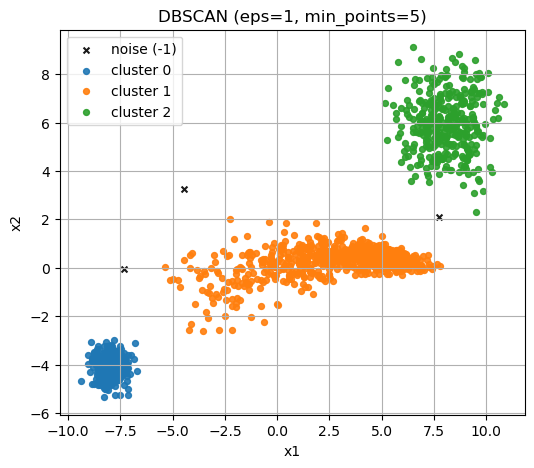

In [5]:
import numpy as np
from sklearn.cluster import DBSCAN

# Vary these
EPS = 1         # epsilon=neighbourhood radius 
MIN_POINTS = 5     # min_samples = min_points

# Fit DBSCAN and get labels
labels = DBSCAN(eps=EPS, min_samples=MIN_POINTS).fit_predict(X)

#labels: -1 = noise; 0,1,2,... = cluster IDs

# Example usage:
plot_clustering_result(X, labels, EPS, MIN_POINTS, title=f"DBSCAN (eps={EPS}, min_points={MIN_POINTS})")